# Problem 5

### Problem
$$
\begin{align*}
u(x, y) &= \sin(\alpha \pi (x + y)), \\
\end{align*}
$$

From the Paper:
This solution and the respective function $f(x, y) = -2 \alpha^{2} \pi^{2} \sin(\alpha \pi (x + y))$ present rapidly growing derivatives for large values of $\alpha$. In Tables VIII and IX we present relative errors in the norm $\|\cdot\|_{\infty}$ when solving the Dirichlet problem for $\alpha = 5$ and $\alpha = 20$, respectively. Here we have adopted the trapezoidal rule for evaluating the radial integrals.

For the case $\alpha = 5$ the dominant parameter is the number of circles $M$ regardless of the number of Fourier coefficients in use. In fact, quadratic convergence depending on $M$ can be observed in Table VIII. For the larger value $\alpha = 20$ functions $u$ and $f$ oscillate rapidly, and the derivatives increase in absolute value.

The Fourier spaces of dimension $N = 64$ and $N = 128$ do not allow a good representation of $u$ and $f$ as one can observe on the first two rows of relative residual in Table IX. However, for $N = 256$ or larger, the Fourier space provides a good representation of these functions, and the quadratic convergence on $M$ resumes (rows 3, 4, 5, and 6 in Table IX). This problem shows the importance of using Fourier representation when dealing with rapidly oscillating functions.

# Imports

In [7]:
import os
import sys
from pathlib import Path

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = False  # Set to True for NVIDIA GPU acceleration

# Auto-detect Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('Poisson_Solver'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git')
        if os.path.exists('NUFFTRR_Poisson'):
            os.chdir('NUFFTRR_Poisson')
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')

# Dynamic repository root and helper path resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

# Solver Parameters (Uniform Grid)
num_processors = None  # Number of CPU threads (None = all available cores)

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = False  # Set to True to run each test 5 times and record min runtime
NUM_RUNS = 5 if TIME_TRIALS else 1

backend_name = 'GPU (NVIDIA CuPy / cuFFT)' if USE_GPU else 'CPU (Multithreaded FFTW)'
print('=' * 60)
print(f'  Executing Test Suite on: {backend_name}')
print('=' * 60)
from uniform_testing_helpers_2 import *
set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS, use_gpu=USE_GPU)


# Problem Setup

In [8]:

R = 1.0
rad_unif = 1
BC_MAP = {"dirichlet": 1, "neumann": 2}
QUAD_MAP = {"trapezoidal": 1, "simpson": 2}

methods = [
    {"name": "fft", "label": "Uniform FFT", "azu_unif": 2, "mesh_kind": "uniform", "use_nudft": False}
]

N_values = [64, 128, 256, 512, 1024, 2048]
M_values = [64, 128, 256, 512, 1024, 2048]
alphas = [5, 20]


# Run Code, table 

In [9]:

df_tables = {}
runtime_summary = []

for alpha in tqdm(alphas, desc="Problem 5 (alpha loop)", unit="alpha"):
    u, f, g_dirichlet, g_neumann = setup_problem_5(alpha)

    t0 = time.perf_counter()
    df_tables[alpha] = run_table_1_tracked(
        methods, N_values, M_values, u, f, g_dirichlet, g_neumann,
        BC_MAP, QUAD_MAP, rad_unif, R, desc=f"alpha={alpha}"
    )
    total_time = time.perf_counter() - t0

    runtime_summary.append({
        "alpha": alpha,
        "n_cases": len(N_values) * len(M_values),
        "total_time_s": total_time,
        "avg_time_per_case_s": total_time / (len(N_values) * len(M_values)),
    })

df_runtime = pd.DataFrame(runtime_summary)

Problem 5 (alpha loop):   0%|          | 0/2 [00:00<?, ?alpha/s]

Problem 5 (alpha loop): 100%|██████████| 2/2 [00:45<00:00, 22.96s/alpha]


# View Results

In [10]:
def dash_if_nan(x):
    return "—" if pd.isna(x) else f"{x:.1e}"

for alpha in alphas:
    print(f"\n{'='*80}\nUniform FFT : PROBLEM 5 (alpha={alpha}) - L_inf_rel\n{'='*80}")
    display(df_tables[alpha].pivot(index="N", columns="M", values="L_inf_rel").reindex(index=N_values, columns=M_values).map(dash_if_nan))



Uniform FFT : PROBLEM 5 (alpha=5) - L_inf_rel


M,64,128,256,512,1024,2048
N,,,,,,
64,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.4e-05
128,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05
256,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05
512,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05
1024,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05
2048,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05



Uniform FFT : PROBLEM 5 (alpha=20) - L_inf_rel


M,64,128,256,512,1024,2048
N,,,,,,
64,2.6e+01,2.5e+01,2.5e+01,2.5e+01,2.5e+01,2.5e+01
128,2.2e+00,2.1e+00,2.1e+00,2.1e+00,2.1e+00,2.1e+00
256,2.8e-01,6.5e-02,1.6e-02,4.0e-03,1.0e-03,4.0e-03
512,2.8e-01,6.5e-02,1.6e-02,4.0e-03,1.0e-03,4.0e-03
1024,2.8e-01,6.5e-02,1.6e-02,4.0e-03,1.0e-03,4.0e-03
2048,2.8e-01,6.5e-02,1.6e-02,4.0e-03,1.0e-03,4.0e-03


## Figures from Original Paper


<div style="max-width:500px;">

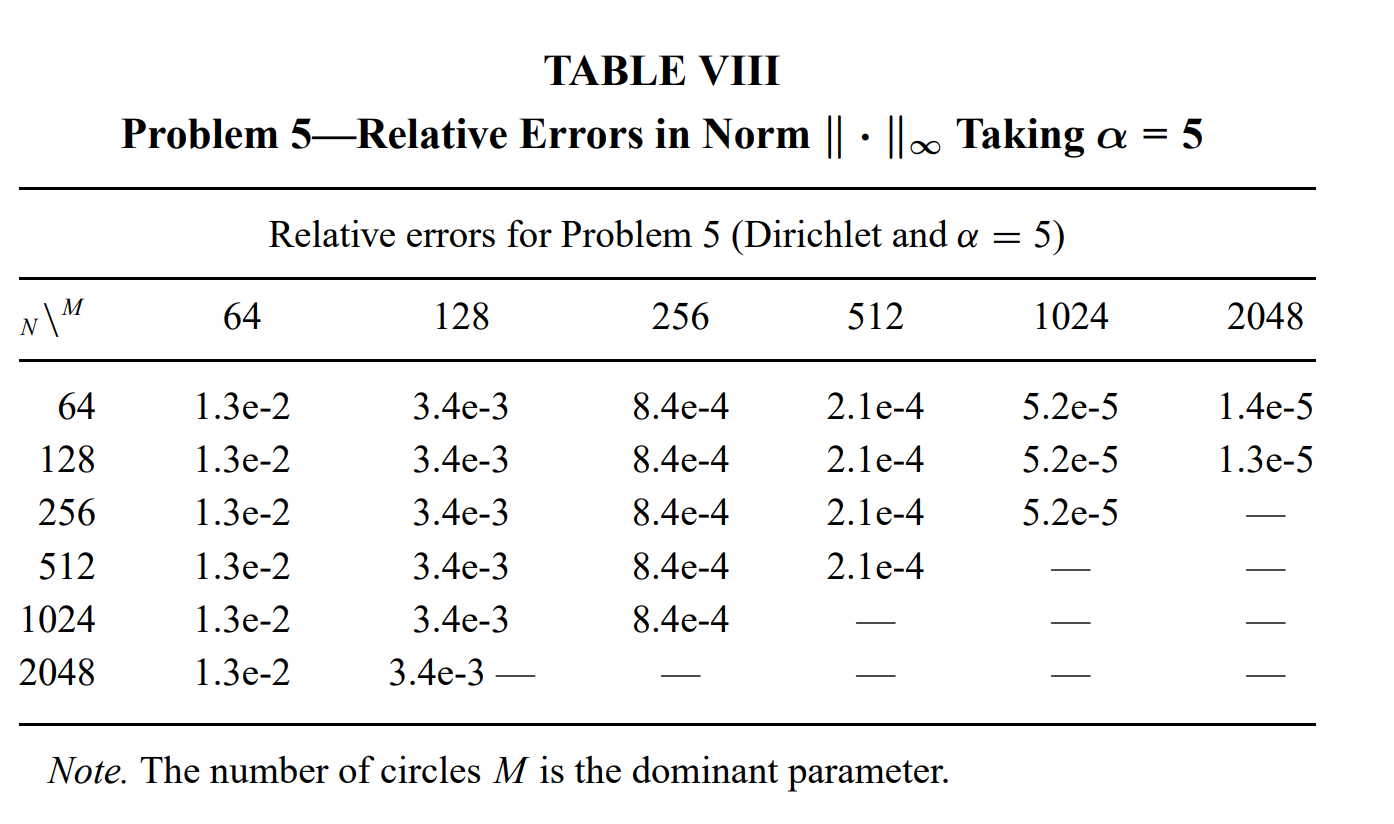

</div>


<div style="max-width:500px;">

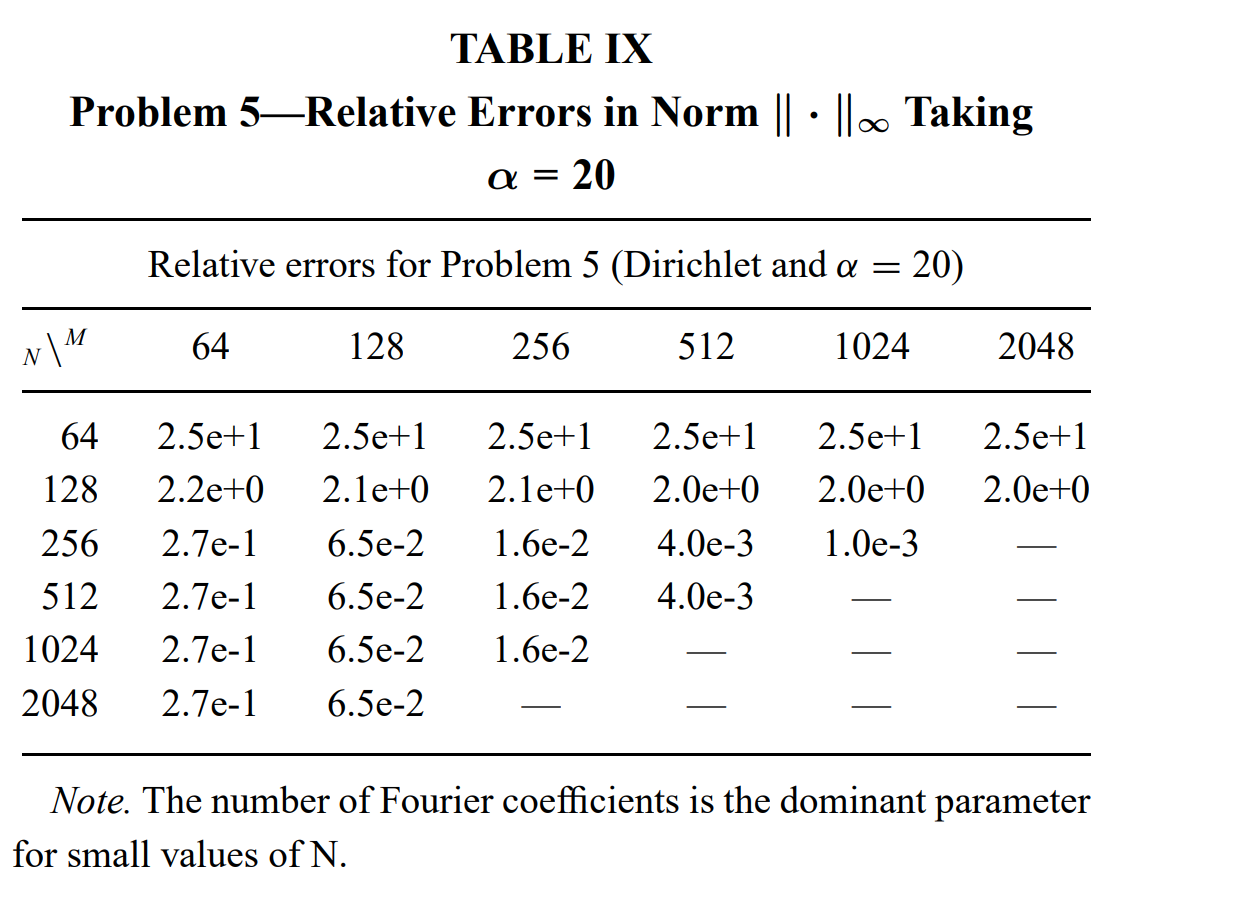

</div>

# Plots and Runtimes

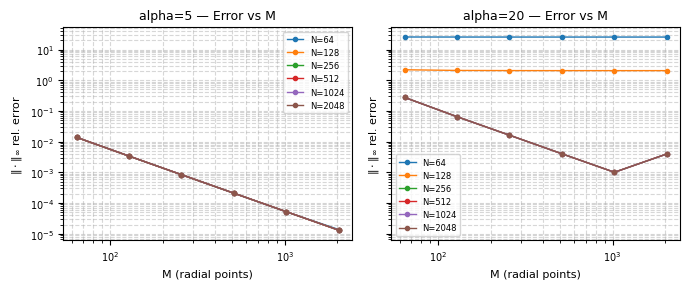

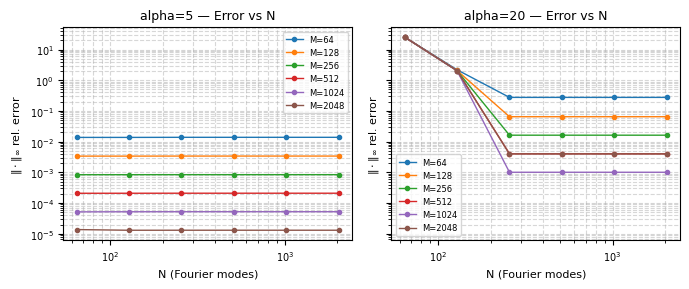


Uniform FFT : PROBLEM 5 (alpha=5) - Solver Time (s)


M,64,128,256,512,1024,2048
N,,,,,,
64,0.311,0.042,0.068,0.135,0.233,0.592
128,0.157,0.123,0.160,0.271,0.731,0.730
256,0.220,0.131,0.219,0.383,0.898,1.606
512,0.300,0.170,0.335,0.356,0.523,1.020
1024,0.286,0.117,0.208,0.407,0.849,1.791
2048,0.410,0.190,0.364,0.743,1.583,3.055



Uniform FFT : PROBLEM 5 (alpha=20) - Solver Time (s)


M,64,128,256,512,1024,2048
N,,,,,,
64,0.016,0.022,0.029,0.054,0.096,0.196
128,0.038,0.046,0.070,0.129,0.374,0.493
256,0.031,0.048,0.085,0.177,0.302,0.591
512,0.054,0.074,0.127,0.227,0.444,0.853
1024,0.069,0.101,0.198,0.393,0.819,1.587
2048,0.128,0.191,0.388,0.695,1.346,2.877



RUNTIME SUMMARY


,alpha,n_cases,total_time_s,avg_time_per_case_s
0,5,36,26.775376,0.743760
1,20,36,18.761804,0.521161


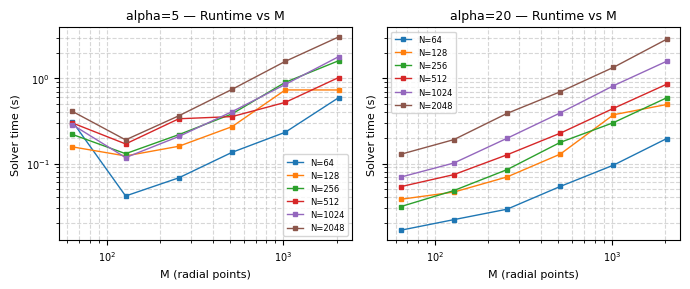

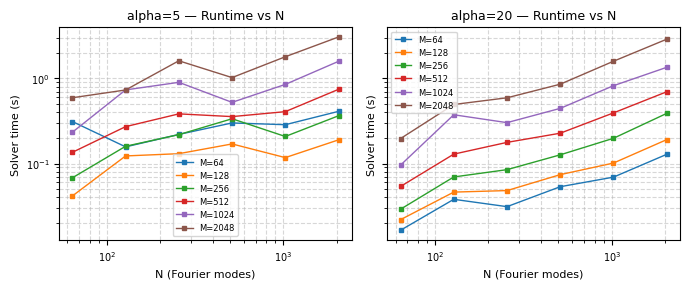

In [11]:


# --- Plots: error & runtime vs M (faceted by alpha) ---
fig, axes = plt.subplots(1, len(alphas), figsize=(3.5 * len(alphas), 3), sharey=True)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    df_a = df_tables[alpha]
    for N in N_values:
        sub = df_a[df_a["N"] == N].sort_values("M")
        ax.loglog(sub["M"], sub["L_inf_rel"], marker="o", markersize=3, linewidth=1, label=f"N={N}")
    ax.set_xlabel("M (radial points)", fontsize=8)
    ax.set_ylabel(r"$\|\cdot\|_\infty$ rel. error", fontsize=8)
    ax.set_title(f"alpha={alpha} — Error vs M", fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(alphas), figsize=(3.5 * len(alphas), 3), sharey=True)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    df_a = df_tables[alpha]
    for M in M_values:
        sub = df_a[df_a["M"] == M].sort_values("N")
        ax.loglog(sub["N"], sub["L_inf_rel"], marker="o", markersize=3, linewidth=1, label=f"M={M}")
    ax.set_xlabel("N (Fourier modes)", fontsize=8)
    ax.set_ylabel(r"$\|\cdot\|_\infty$ rel. error", fontsize=8)
    ax.set_title(f"alpha={alpha} — Error vs N", fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Per-case timing tables
for alpha in alphas:
    print(f"\n{'='*80}\nUniform FFT : PROBLEM 5 (alpha={alpha}) - Solver Time (s)\n{'='*80}")
    display(df_tables[alpha].pivot(index="N", columns="M", values="time").reindex(index=N_values, columns=M_values).map(lambda x: "—" if pd.isna(x) else f"{x:.3f}"))

# Overall runtime summary table
print(f"\n{'='*80}\nRUNTIME SUMMARY\n{'='*80}")
display(df_runtime)



fig, axes = plt.subplots(1, len(alphas), figsize=(3.5 * len(alphas), 3), sharey=True)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    df_a = df_tables[alpha]
    for N in N_values:
        sub = df_a[df_a["N"] == N].sort_values("M")
        ax.loglog(sub["M"], sub["time"], marker="s", markersize=3, linewidth=1, label=f"N={N}")
    ax.set_xlabel("M (radial points)", fontsize=8)
    ax.set_ylabel("Solver time (s)", fontsize=8)
    ax.set_title(f"alpha={alpha} — Runtime vs M", fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, len(alphas), figsize=(3.5 * len(alphas), 3), sharey=True)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    df_a = df_tables[alpha]
    for M in M_values:
        sub = df_a[df_a["M"] == M].sort_values("N")
        ax.loglog(sub["N"], sub["time"], marker="s", markersize=3, linewidth=1, label=f"M={M}")
    ax.set_xlabel("N (Fourier modes)", fontsize=8)
    ax.set_ylabel("Solver time (s)", fontsize=8)
    ax.set_title(f"alpha={alpha} — Runtime vs N", fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()